# Exploring the Midas Open Station Dataset

In [1]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs

## Retriving the Midas Data

In [2]:
base_path = '/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data'
subset = 'uk-daily-temperature-obs'
version = '202507'

full_path = f'{base_path}/{subset}/dataset-version-{version}'
print(f'Full path: {full_path}')

Full path: /data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-daily-temperature-obs/dataset-version-202507


In [3]:
metadata_path = f'{full_path}/midas-open_{subset}_dv-{version}_station-metadata.csv'
print(f'Metadata path: {metadata_path}')


Metadata path: /data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-daily-temperature-obs/dataset-version-202507/midas-open_uk-daily-temperature-obs_dv-202507_station-metadata.csv


The meta data in the format we want starts on the 49th row.

We also want to QC the data by remove NaNs and setting the index to the station id. 

In [4]:
metadata_df = pd.read_csv(metadata_path, skiprows=48)

metadata_df = metadata_df[metadata_df['station_name'].notna()].set_index('src_id')
metadata_df.head()

,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
src_id,,,,,,,,,
00001,FOULA,foula,shetland,Met Office,60.154,-2.074,22.0,1985.0,2003.0
00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,1974.0,2024.0
00004,SUMBURGH,sumburgh,shetland,Met Office,59.879,-1.299,7.0,1978.0,1996.0
00005,HAMNAVOE,hamnavoe,shetland,Met Office,60.104,-1.333,21.0,1962.0,1973.0
00006,SCATSTA,scatsta,shetland,Met Office,60.439,-1.308,15.0,1979.0,1980.0


Visualising stations on the map. We are using the PlateCarree projection, are there other projections that work?

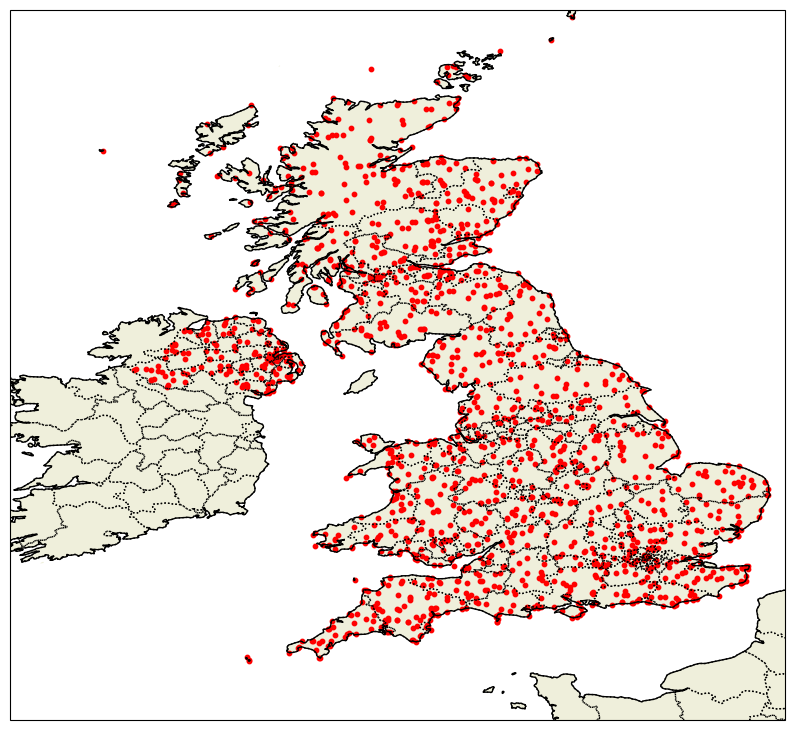

In [5]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=cartopy.crs.PlateCarree())
ax.set_extent([-10, 2, 49, 60], crs=cartopy.crs.PlateCarree())
ax.add_feature(cartopy.feature.LAND)
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.STATES, linestyle=':')

ax.scatter(metadata_df['station_longitude'], metadata_df['station_latitude'], color='red', s=10, transform=cartopy.crs.PlateCarree())
plt.show()

The 2022 July heat wave 17th - 19th July

On 19 July, a temperature of 40.3 °C was recorded at Coningsby, Lincolnshire, the hottest temperature ever recorded in the United Kingdom. Before that day, the previous record of 38.7 °C was recorded in Cambridge during the 2019 European heatwaves

Lets compare the temperature at Coningsby. Fortunatly the Coningsby is the site for a station so we can use it for the name and it 46 years of data.

In [6]:
station_name = 'coningsby'
station_metadata = metadata_df[metadata_df['station_file_name'] == station_name]

In [7]:
station_metadata

,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
src_id,,,,,,,,,
00393,CONINGSBY,coningsby,lincolnshire,Met Office,53.094,-0.173,6.0,1978.0,2024.0


Now we can locate all the data files and construct a dataframe for analysis.
First we need to build in the parameters

Change skiprows based on parameter

In [8]:
station_id = station_metadata.index[0]
station_country = station_metadata['historic_county'].values[0]
station_date_range = [int(station_metadata['first_year'].values[0]), int(station_metadata['last_year'].values[0])]

data_base_path = f'{full_path}/{station_country}/{station_id}_{station_name}/qc-version-1'

selected_station_dataframe = pd.DataFrame()
for year in range(station_date_range[0], station_date_range[1] + 1):
    data_file_path = f'{data_base_path}/midas-open_{subset}_dv-202507_{station_country}_{station_id}_{station_name}_qcv-1_{year}.csv'
    yearly_data_df = pd.read_csv(data_file_path, skiprows=93, skipfooter=1, engine="python") # Each file has an end footer saying end data
    selected_station_dataframe = pd.concat([selected_station_dataframe, yearly_data_df])


In [9]:
# remove rows where ob_end_time is end date
selected_station_dataframe.head()

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,max_air_temp,min_air_temp,...,max_air_temp_q,min_air_temp_q,min_grss_temp_q,min_conc_temp_q,max_air_temp_j,min_air_temp_j,min_grss_temp_j,min_conc_temp_j,meto_stmp_time,midas_stmp_etime
0,1978-04-01 09:00:00,DCNN,2464,12,1,NCM,393,1001,9.4,7.4,...,9.0,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1978-04-01 21:00:00,DCNN,2464,12,1,NCM,393,1001,11.8,8.9,...,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1978-04-02 09:00:00,DCNN,2464,12,1,NCM,393,1001,9.0,4.2,...,9.0,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1978-04-02 21:00:00,DCNN,2464,12,1,NCM,393,1001,14.1,5.7,...,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1978-04-03 09:00:00,DCNN,2464,12,1,NCM,393,1001,6.3,5.1,...,9.0,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleansing

In [10]:
selected_station_dataframe = selected_station_dataframe.dropna(subset=['id'], axis=0)
selected_station_dataframe['ob_end_time'] = pd.to_datetime(selected_station_dataframe['ob_end_time'])
selected_station_dataframe = selected_station_dataframe[selected_station_dataframe['ob_end_time'].dt.month == 7]


In [11]:
random_sample = selected_station_dataframe.sample(n=10, random_state=123).sort_values(by='ob_end_time')
random_sample

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,max_air_temp,min_air_temp,...,max_air_temp_q,min_air_temp_q,min_grss_temp_q,min_conc_temp_q,max_air_temp_j,min_air_temp_j,min_grss_temp_j,min_conc_temp_j,meto_stmp_time,midas_stmp_etime
380,1979-07-10 09:00:00,DCNN,2464,12,1,NCM,393,1001,15.2,8.1,...,9.0,9.0,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
401,1998-07-20 21:00:00,DCNN,2464,12,1,NCM,393,1011,27.2,20.6,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1998-07-20 21:03:00,11974.0
407,1998-07-23 21:00:00,DCNN,2464,12,1,NCM,393,1011,21.8,14.8,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1998-07-23 21:09:00,7648.0
383,1999-07-11 21:00:00,DCNN,2464,12,1,NCM,393,1011,23.6,16.7,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1999-07-13 09:57:00,11235.0
381,2002-07-10 21:00:00,DCNN,2464,12,1,NCM,393,1011,20.5,13.2,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2002-07-10 21:01:00,9504.0
387,2011-07-13 21:00:00,DCNN,2464,12,1,NCM,393,1011,17.0,12.7,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2011-07-13 20:58:00,0.0
390,2015-07-15 09:00:00,DCNN,2464,12,1,NCM,393,1011,16.6,13.7,...,6.0,6.0,6.0,6.0,NaN,NaN,NaN,NaN,2015-07-15 08:56:00,0.0
393,2016-07-15 21:00:00,DCNN,2464,12,1,NCM,393,1011,19.8,16.6,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2016-07-15 20:56:00,0.0
424,2020-07-31 09:00:00,DCNN,2464,12,1,NCM,393,1011,26.5,12.3,...,6.0,6.0,6.0,6.0,NaN,NaN,NaN,NaN,2020-07-31 09:00:00,0.0
393,2023-07-16 21:00:00,DCNN,2464,12,1,NCM,393,1011,21.9,14.2,...,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2023-07-16 21:05:00,0.0


Temperature Distribution

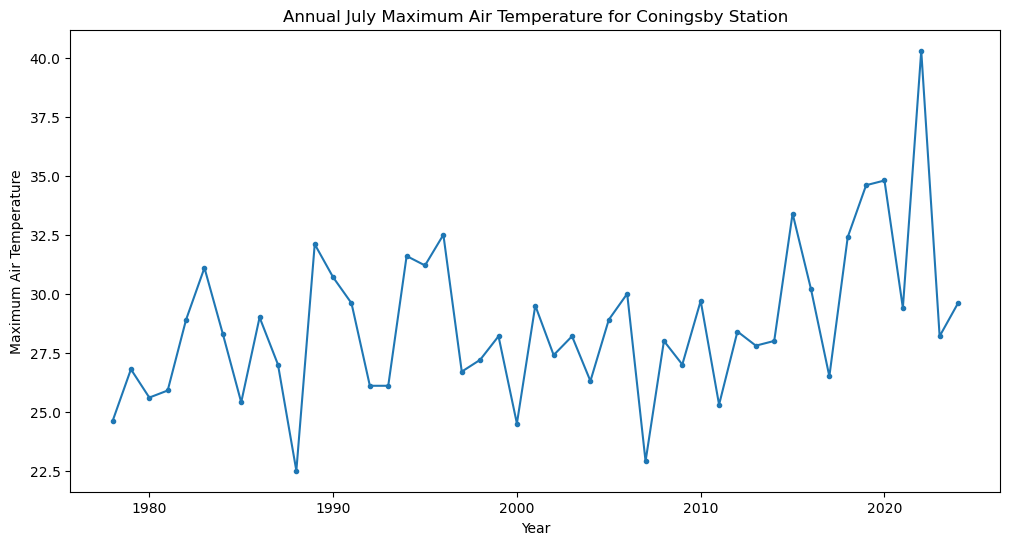

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(selected_station_dataframe.groupby(selected_station_dataframe['ob_end_time'].dt.year)['max_air_temp'].max(), marker='o', linestyle='-', markersize=3)
plt.title(f'Annual July Maximum Air Temperature for {station_name.capitalize()} Station')
plt.xlabel('Year')
plt.ylabel('Maximum Air Temperature')
plt.show()


Plotting the max temp every day for each year. To visuallise the heatwave

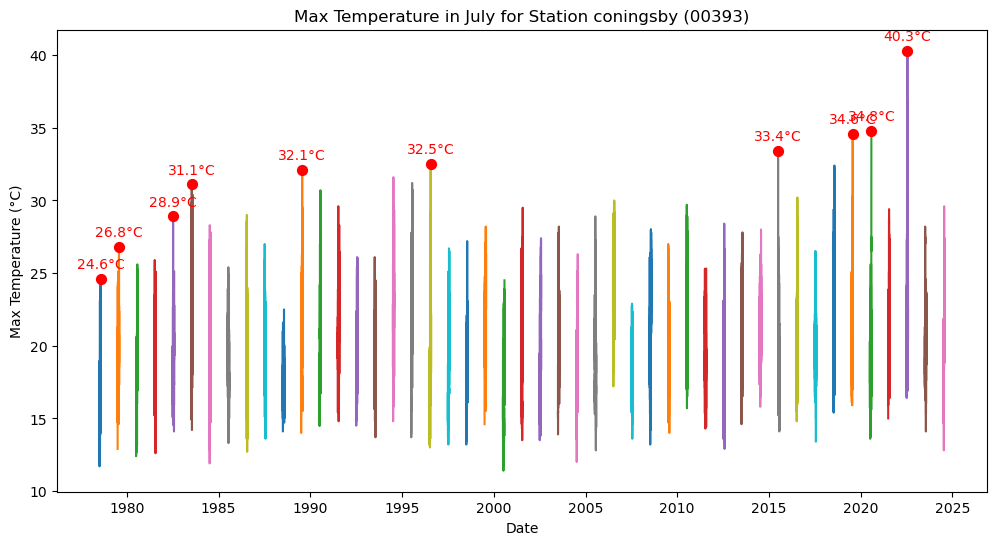

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
previous_max = None
for year in range(station_date_range[0], station_date_range[1] + 1):
    yearly_data = selected_station_dataframe[selected_station_dataframe['ob_end_time'].dt.year == year]
    ax.plot(yearly_data['ob_end_time'], yearly_data['max_air_temp'])
    ax.set_title(f'Max Temperature in July for Station {station_name} ({station_id})')
    ax.set_xlabel('Date')
    ax.set_ylabel('Max Temperature (°C)')

    # Adding a marker for the maximum temperature in July for where the maximum temperature was higher that the previous maximum temperature
    max_temp = yearly_data['max_air_temp'].max()
    if previous_max is None or max_temp > previous_max:
        max_temp_date = yearly_data[yearly_data['max_air_temp'] == max_temp]['ob_end_time'].iloc[0]
        ax.scatter(max_temp_date, max_temp, color='red', s=50, zorder=5)
        # Add a text label for the maximum temperature, ensure that text label does not overlap with the previous maximum temperature label
        ax.text(max_temp_date, max_temp + 0.5, f'{max_temp:.1f}°C', color='red', ha='center', va='bottom', fontsize=10)
        previous_max = max_temp


plt.show()

Lets create an average based on 20 years of data, 1990 - 2010 and see how each month deviates from the average.

In [14]:
year_avg_df = selected_station_dataframe[(selected_station_dataframe['ob_end_time'].dt.year >= 1990) & (selected_station_dataframe['ob_end_time'].dt.year <= 2010) & (selected_station_dataframe['ob_end_time'].dt.month <= 7)]
average_temperature = year_avg_df.groupby(year_avg_df['ob_end_time'].dt.month)['max_air_temp'].mean()
selected_station_dataframe['Distance_from_Average'] = selected_station_dataframe.apply(lambda row: row['max_air_temp'] - average_temperature[row['ob_end_time'].month], axis=1)

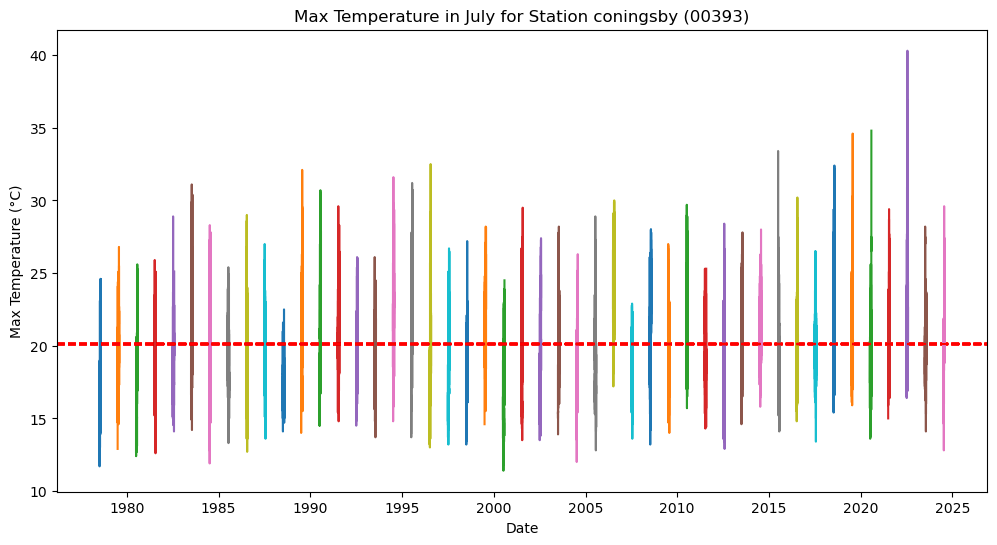

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
for year in range(station_date_range[0], station_date_range[1] + 1):
    yearly_data = selected_station_dataframe[selected_station_dataframe['ob_end_time'].dt.year == year]
    ax.plot(yearly_data['ob_end_time'], yearly_data['max_air_temp'])
    ax.axhline(y=average_temperature[7], color='r', linestyle='--', label='Average Temperature (1990-2010)')
    ax.set_title(f'Max Temperature in July for Station {station_name} ({station_id})')
    ax.set_xlabel('Date')
    ax.set_ylabel('Max Temperature (°C)')
plt.show()



You could expand by looking at the previous record from Cambridge and compare the two. You could also look at another parameter measured by the station.